In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
# from ydata_profiling import ProfileReport # подробный разбор признаков
import os
from datetime import datetime
from typing import Dict, List, Optional, Union
import matplotlib.pyplot as plt
import re

In [2]:
df0 = pd.read_csv('combined_with_dates.csv')

In [3]:
df = df0.copy()

In [4]:
display(df)
display(df.info())

,ID,Task_Name,Task_ID,Workflow_Name,Plan_Name,CALL_ID,Phone_Number,Call_Time,Answer_Time,End_Time,Robot,Platform,Duration(s),Talk_Round,Ring_Type,Hang_Type,Ring_Time,Intention,Event_Labels,ASR_Result,Status,Summary,DueDate/due_date,Case ID,comments,day
0,4295519152,250601_0000041813_Robot_DPD_0_14:30_New,3b3a22e4f93845bea1a34ddb6658d1bf,NaN,NaN,NaN,5298441204199,NaN,NaN,NaN,M0_L2_MX_ES_Adr_COZMO_DM2_v4,COZMO,0,0,NaN,Cancelled,0,--,NaN,NaN,cancelled,NaN,2025-06-01,NaN,NaN,1
1,4295519151,250601_0000041813_Robot_DPD_0_14:30_New,3b3a22e4f93845bea1a34ddb6658d1bf,NaN,NaN,NaN,5293324176190,NaN,NaN,NaN,M0_L2_MX_ES_Adr_COZMO_DM2_v4,COZMO,0,0,NaN,Cancelled,0,--,NaN,NaN,cancelled,NaN,2025-06-01,NaN,NaN,1
2,4295519044,250601_0000041817_Robot_DPD_-3_18_00_New_first,e9b7794e60b94f668cbc2daa569ba87d,NaN,NaN,NaN,5298181111775,NaN,NaN,NaN,M0_L2_MX_ES_Adr_COZMO_DM2_v4,COZMO,0,0,NaN,Cancelled,0,--,NaN,NaN,cancelled,NaN,2025-06-04,NaN,NaN,1
3,4295519043,250601_0000041817_Robot_DPD_-3_18_00_New_first,e9b7794e60b94f668cbc2daa569ba87d,NaN,NaN,NaN,5299511892676,NaN,NaN,NaN,M0_L2_MX_ES_Adr_COZMO_DM2_v4,COZMO,0,0,NaN,Cancelled,0,--,NaN,NaN,cancelled,NaN,2025-06-04,NaN,NaN,1
4,4295519042,250601_0000041817_Robot_DPD_-3_18_00_New_first,e9b7794e60b94f668cbc2daa569ba87d,NaN,NaN,NaN,5297718885813,NaN,NaN,NaN,M0_L2_MX_ES_Adr_COZMO_DM2_v4,COZMO,0,0,NaN,Cancelled,0,--,NaN,NaN,cancelled,NaN,2025-06-04,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127343,4418806719,250620_0000045610_Robot_DPD_0_07_45_Repeat,89d5f67db665426a907225e15cd86265,NaN,NaN,a446c0d7bba94924acb24931525df04e,5299541627817,2025-06-20 07:45:07,2025-06-20 07:45:17,2025-06-20 07:45:19,M0_L2_MX_ES_Adr_COZMO_DM2_v4,COZMO,2,1,outofarea,ByRobot,8,G,NaN,00:00:00 Robot: Muy buenos días.\n00:00:01 Use...,finished,NaN,2025-06-20,NaN,NaN,20
127344,4418806717,250620_0000045610_Robot_DPD_0_07_45_Repeat,89d5f67db665426a907225e15cd86265,NaN,NaN,95830042fa1e406d9f42faf9b17e607b,5295549335675,2025-06-20 07:45:07,2025-06-20 07:45:36,2025-06-20 07:45:38,M0_L2_MX_ES_Adr_COZMO_DM2_v4,COZMO,2,1,normal,ByRobot,27,G,NaN,00:00:00 Robot: Muy buenos días.\n00:00:01 Use...,finished,NaN,2025-06-20,NaN,NaN,20
127345,4418806715,250620_0000045610_Robot_DPD_0_07_45_Repeat,89d5f67db665426a907225e15cd86265,NaN,NaN,ce2e655fb9c14be8997a3607e1687ea5,5296631093099,2025-06-20 07:45:07,2025-06-20 07:45:17,2025-06-20 07:45:18,M0_L2_MX_ES_Adr_COZMO_DM2_v4,COZMO,1,1,busy,ByRobot,8,G,NaN,00:00:00 Robot: Muy buenos días.\n00:00:01 Use...,finished,NaN,2025-06-20,NaN,NaN,20
127346,4418806714,250620_0000045610_Robot_DPD_0_07_45_Repeat,89d5f67db665426a907225e15cd86265,NaN,NaN,d7cf876c7da843d1862d75efcb8045bf,5295575666770,2025-06-20 07:45:07,2025-06-20 07:45:17,2025-06-20 07:45:19,M0_L2_MX_ES_Adr_COZMO_DM2_v4,COZMO,2,1,normal,ByRobot,8,G,NaN,00:00:00 Robot: Muy buenos días.\n00:00:01 Use...,finished,NaN,2025-06-20,NaN,NaN,20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127348 entries, 0 to 127347
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                127348 non-null  int64  
 1   Task_Name         127348 non-null  object 
 2   Task_ID           127348 non-null  object 
 3   Workflow_Name     0 non-null       float64
 4   Plan_Name         2369 non-null    object 
 5   CALL_ID           93518 non-null   object 
 6   Phone_Number      127348 non-null  int64  
 7   Call_Time         93518 non-null   object 
 8   Answer_Time       89009 non-null   object 
 9   End_Time          93518 non-null   object 
 10  Robot             127348 non-null  object 
 11  Platform          127348 non-null  object 
 12  Duration(s)       127348 non-null  int64  
 13  Talk_Round        127348 non-null  int64  
 14  Ring_Type         93518 non-null   object 
 15  Hang_Type         127348 non-null  object 
 16  Ring_Time         12

None

In [55]:
def prepare(df: pd.DataFrame, 
            drops: list = None, 
            inffo: bool = False,
            plot_pie: bool = False) -> pd.DataFrame:
    """
    Подготавливает DataFrame с возможностью визуализации распределения данных.
    
    Параметры:
        df: Исходный DataFrame
        drops: Список столбцов для удаления
        inffo: Флаг вывода подробной информации о столбцах
        plot_pie: Флаг построения круговых диаграмм для каждого столбца
    
    Возвращает:
        Обработанный DataFrame
    """
    if drops is None:
        drops = []

    # Поиск полностью пустых столбцов
    for col in df.columns:
        lenns = len(df[col])
        nans = df[col].isna().sum()
        
        if lenns == nans:
            drops.append(col)
        
        if inffo:
            print(f"\nСтолбец: {col}")
            print(df[col].value_counts(dropna=False))
            print(f'Всего: {lenns} | Полных: {lenns - nans} | Пустых: {nans}')
            print('-' * 50)

        # Построение pie-диаграмм
        if plot_pie and col not in drops:
            plt.figure(figsize=(8, 4))
            
            # Для числовых данных - гистограмма
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col].plot(kind='hist', title=f'Распределение {col}')
                plt.ylabel('Количество')
            
            # Для категориальных - pie chart
            else:
                value_counts = df[col].value_counts(dropna=False)
                if len(value_counts) > 10:  # Ограничение для слишком разнообразных данных
                    top10 = value_counts.head(10)
                    top10['Остальные'] = value_counts[10:].sum()
                    top10.plot(kind='pie', autopct='%1.1f%%', title=f'Top-10 значений {col}')
                else:
                    value_counts.plot(kind='pie', autopct='%1.1f%%', title=f'Распределение {col}')
            
            plt.tight_layout()
            plt.show()

    # Удаление указанных столбцов
    df = df.drop(columns=drops, errors='ignore')
    
    # Вывод информации
    print("\nОбщая информация о DataFrame:")
    print(df.info())
    
    if drops:
        print('-' * 100)
        print(f'Удаленные признаки: {drops}')

    return df

In [6]:
# Удалим незаполненные признаки
df_prepared = prepare(df)


Общая информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127348 entries, 0 to 127347
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                127348 non-null  int64  
 1   Task_Name         127348 non-null  object 
 2   Task_ID           127348 non-null  object 
 3   Plan_Name         2369 non-null    object 
 4   CALL_ID           93518 non-null   object 
 5   Phone_Number      127348 non-null  int64  
 6   Call_Time         93518 non-null   object 
 7   Answer_Time       89009 non-null   object 
 8   End_Time          93518 non-null   object 
 9   Robot             127348 non-null  object 
 10  Platform          127348 non-null  object 
 11  Duration(s)       127348 non-null  int64  
 12  Talk_Round        127348 non-null  int64  
 13  Ring_Type         93518 non-null   object 
 14  Hang_Type         127348 non-null  object 
 15  Ring_Time         127348 non-null  in

### Удаляем признаки
 - ID - все значения уникальны
 - Task_ID - все значения совпадают с Task_Name и не содержат информации
 - Platform - все значения одинаковы

In [7]:
df_prepared = prepare(df_prepared, ['ID', 'Task_ID', 'Platform', 'comments'], inffo=True)


Столбец: ID
ID
4295519152    1
4373100288    1
4373100828    1
4373103814    1
4373104275    1
             ..
4328696567    1
4328682969    1
4328581825    1
4328581873    1
4418806708    1
Name: count, Length: 127348, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------

Столбец: Task_Name
Task_Name
250604_0000042477_Robot_DPD_2_8:30             626
250604_0000042469_Robot_DPD_2_18:30            545
250604_0000042435_Robot_DPD_-5_12_30_Repeat    475
250604_0000042446_Robot_DPD_-5_18_00_Repeat    475
250604_0000042425_Robot_DPD_-5_10_30_Repeat    475
                                              ... 
250607_0000043156_Robot_DPD_-2_10_30_New         1
250607_0000043107_Robot_DPD_-4_10_30_Repeat      1
250607_0000043088_Robot_DPD_-2_12_30_New         1
250607_0000043114_Robot_DPD_-4_12_30_Repeat      1
250606_0000042907_Robot_DPD_-5_07_45_Repeat      1
Name: count, Length: 1714, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 

## Предобработка признаков

### Task_Name

In [8]:
def split_task_name(task_name):
    parts = task_name.split('_')
    dt = parts[0]
    num = parts[1]
    rob = '-'.join(parts[2:4])
    bill = parts[4]
    
    # Проверяем наличие статуса в конце
    status = None
    time_parts = parts[5:]
    
    # Если последняя часть содержит буквы - это статус
    if len(time_parts) > 0 and any(c.isalpha() for c in time_parts[-1]):
        status = time_parts[-1]
        time_parts = time_parts[:-1]
    
    # Если предпоследняя часть тоже содержит буквы (как в New_first)
    if len(time_parts) > 0 and any(c.isalpha() for c in time_parts[-1]):
        status = f"{time_parts[-1]}_{status}" if status else time_parts[-1]
        time_parts = time_parts[:-1]
    
    time_part = '_'.join(time_parts) if time_parts else None
           
    return pd.Series([dt, num, rob, bill, time_part, status])

# Применяем функцию к DataFrame
df_prepared[['Task_Name_dt', 'Task_Name_num', 'Task_Name_rob', 'Task_Name_bill', 'Task_Name_time', 'Task_Name_status']] = df_prepared['Task_Name'].apply(split_task_name)

In [9]:
display(df_prepared[['Task_Name_dt', 'Task_Name_num', 'Task_Name_rob', 'Task_Name_bill', 'Task_Name_time', 'Task_Name_status']])

,Task_Name_dt,Task_Name_num,Task_Name_rob,Task_Name_bill,Task_Name_time,Task_Name_status
0,250601,0000041813,Robot-DPD,0,14:30,New
1,250601,0000041813,Robot-DPD,0,14:30,New
2,250601,0000041817,Robot-DPD,-3,18_00,New_first
3,250601,0000041817,Robot-DPD,-3,18_00,New_first
4,250601,0000041817,Robot-DPD,-3,18_00,New_first
...,...,...,...,...,...,...
127343,250620,0000045610,Robot-DPD,0,07_45,Repeat
127344,250620,0000045610,Robot-DPD,0,07_45,Repeat
127345,250620,0000045610,Robot-DPD,0,07_45,Repeat
127346,250620,0000045610,Robot-DPD,0,07_45,Repeat


In [10]:
df_prepared['Task_Name_dt'].value_counts()

Task_Name_dt
250601      8933
250602      8073
250604      8050
250608      6866
250615      6680
250609      6615
250611      6443
250616      6327
250618      6183
250606      5955
250605      5918
250620      5801
250607      5778
250613      5644
250612      5543
250603      5537
250614      5457
250619      5330
250617      4957
250610      4889
airudder    2369
Name: count, dtype: int64

In [11]:
df_prepared['Task_Name_status'].value_counts()

Task_Name_status
Repeat          62517
New             30271
New_first       15568
Repeat_first    10431
New_frist        1403
Name: count, dtype: int64

#### В признаке Task_Name_dt оставляем месяц, день и airudder

In [12]:
def process_task_dates(df, task_col='Task_Name_dt', skip_word='airudder'):
    """
    Преобразует даты в формате DDMMYY, пропуская строки с указанным словом
    
    Параметры:
        df (pd.DataFrame): Входной DataFrame
        task_col (str): Название колонки с датами
        skip_word (str): Слово для пропуска (регистронезависимо)
    
    Возвращает:
        pd.DataFrame: С новой колонкой 'Task_Date'
    """
    # Маска для строк БЕЗ skip_word (регистронезависимая проверка)
    mask = ~df[task_col].astype(str).str.contains(skip_word, case=False, regex=False)
    
    # Преобразуем только допустимые строки
    df.loc[mask, task_col] = pd.to_datetime(
        df.loc[mask, task_col],
        format='%y%m%d',
        errors='coerce'
    ).dt.strftime('%m-%d')  # Формат "месяц-день"
    
    # Для строк с skip_word оставляем исходное значение (или можно задать другое)
    return df

# Обработка
df_prepared = process_task_dates(df_prepared)
df_prepared['Task_Name_dt'].value_counts()

Task_Name_dt
06-01       8933
06-02       8073
06-04       8050
06-08       6866
06-15       6680
06-09       6615
06-11       6443
06-16       6327
06-18       6183
06-06       5955
06-05       5918
06-20       5801
06-07       5778
06-13       5644
06-12       5543
06-03       5537
06-14       5457
06-19       5330
06-17       4957
06-10       4889
airudder    2369
Name: count, dtype: int64

#### Task_Name_time

In [13]:
# Обрабатываем время и заменяем '_' на ':'
df_prepared['Task_Name_time'] = df_prepared['Task_Name_time'].apply(
    lambda x: ':'.join(x[-5:].split('_')) if isinstance(x, str) and '_' in x else x
)

# Удаляем возможное ведущее двоеточие
df_prepared['Task_Name_time'] = df_prepared['Task_Name_time'].str.replace(r'^:', '', regex=True)
df_prepared['Task_Name_time'].value_counts()

Task_Name_time
07:45    37701
18:00    30516
10:30    23959
12:30    18269
14:30     9745
8:30      2521
18:30     2268
Name: count, dtype: int64

#### Task_Name_num

#### Проверим значения в признаке 'Task_Name_num'

In [14]:
df_prepared['Task_Name_num'].value_counts()

Task_Name_num
ptpreminder    2369
0000042477      626
0000042469      545
0000042435      475
0000042454      475
               ... 
0000043156        1
0000043107        1
0000043088        1
0000043114        1
0000042907        1
Name: count, Length: 1693, dtype: int64

In [15]:
df_prepared['Task_Name_num'].apply(lambda x: len(x)).value_counts()

Task_Name_num
10    124979
11      2369
Name: count, dtype: int64

In [16]:
link_tnn = df_prepared[df_prepared['Task_Name_num'] != 'ptpreminder'] # Не проблемные строки в Task_Name_num
# Для строковых колонок
is_all_digits = link_tnn['Task_Name_num'].str.isdigit().all()
print(f"Все значения состоят только из цифр: {is_all_digits}")

Все значения состоят только из цифр: True


In [17]:
link_tn = df_prepared[df_prepared['Task_Name_dt'] == 'airudder'] # Проблемные строки в Task_Name_dt
link_tnn1 = df_prepared[df_prepared['Task_Name_num'] == 'ptpreminder'] # Проблемные строки в Task_Name_num
print(f'Одинаковое кол-во? - {len(link_tnn1) == len(link_tn)}')
len(link_tnn1)
common_indices = link_tn.index.intersection(link_tnn1.index)
print(f"Количество общих индексов: {len(common_indices)}")

Одинаковое кол-во? - True
Количество общих индексов: 2369


#### Удаляем признак Task_Name_num т.к. цифры малозначимы, а ячейки с ptpreminder имеют такие же строки, как и airudder в Task_Name_dt

In [18]:
df_prepared = df_prepared.drop(columns=['Task_Name_num'])

#### Task_Name_rob

In [19]:
df_prepared['Task_Name_rob'].value_counts()

Task_Name_rob
Robot-DPD      124979
jun09-Round       344
jun02-Round       342
jun04-Round       266
jun16-Round       255
jun17-Round       238
jun10-Round       182
jun03-Round       170
jun11-Round       161
jun05-Round       160
jun12-Round       153
jun20-Round        98
Name: count, dtype: int64

In [20]:
link_tn = df_prepared[df_prepared['Task_Name_dt'] == 'airudder'] # Проблемные строки в Task_Name_dt
link_r = df_prepared[df_prepared['Task_Name_rob'] != 'Robot-DPD'] # Проблемные строки в Task_Name_rob
print(f'Одинаковое кол-во? - {len(link_r) == len(link_tn)}')
len(link_tnn1)
common_indices = link_tn.index.intersection(link_r.index)
print(f"Количество общих индексов: {len(common_indices)}")

Одинаковое кол-во? - True
Количество общих индексов: 2369


#### Удаляем признак Task_Name_rob т.к. ячейки без 'Robot-DPD' имеют такие же строки, как и airudder в Task_Name_dt

In [21]:
df_prepared = df_prepared.drop(columns=['Task_Name_rob'])

#### Удаляем оригинальный признак

In [22]:
df_prepared = df_prepared.drop(columns=['Task_Name'])

### Plan_Name

#### Есть подозрение на связь с Task_Name_dt. Оставим проверку на конец обработки. Меняем на месяц, день

In [23]:
df_prepared['Plan_Name'] = df_prepared['Plan_Name'].apply(lambda x: int(x[-2:]) if isinstance(x, str) else -1)
df_prepared['Plan_Name'] = df_prepared['Plan_Name'].apply(
    lambda x: pd.to_datetime(f"2025-06-{x}").strftime('%m-%d') 
    if x > 0 
    else x
)
df_prepared['Plan_Name'].value_counts()

Plan_Name
-1       124979
06-09       344
06-02       342
06-04       266
06-16       255
06-17       238
06-10       182
06-03       170
06-11       161
06-05       160
06-12       153
06-20        98
Name: count, dtype: int64

### CALL_ID

#### Преобразуем в 1 заполненные в 0 - пустые для индикатора наличия звонка

In [24]:
df_prepared['CALL_ID'] = df_prepared['CALL_ID'].apply(lambda x: 1 if isinstance(x, str) else 0)
df_prepared['CALL_ID'].value_counts()

CALL_ID
1    93518
0    33830
Name: count, dtype: int64

### Phone_Number

#### Проверяем, одинаковой ли длины телефоны

In [25]:
lp = df_prepared['Phone_Number'].apply(lambda x: len(str(x)))
lp.value_counts()

Phone_Number
13    127348
Name: count, dtype: int64

#### Проверям первые две цифры на соответствие

In [26]:
kod = df_prepared['Phone_Number'].apply(lambda x: str(x)[:2])
kod.value_counts()

Phone_Number
52    127348
Name: count, dtype: int64

#### Первые две цифры одинаковые- значит из одной местности (Мексика)

#### Создаем признак с кодом оператора

In [27]:
df_prepared['Phone_Code'] = df_prepared['Phone_Number'].apply(lambda x: str(x)[3:6])
df_prepared['Phone_Code'].value_counts()

Phone_Code
554    5011
553    4980
552    4086
551    3559
557    3144
       ... 
463       4
696       4
988       2
823       2
593       2
Name: count, Length: 321, dtype: int64

#### Сам признак делаем категориальным для вычисления частоты обращений

In [28]:
df_prepared['Phone_Number'] = pd.factorize(df_prepared['Phone_Number'])[0]
df_prepared['Phone_Number'].value_counts()

Phone_Number
5684    78
3550    63
1388    61
2007    60
3558    60
        ..
5415     1
2977     1
5411     1
2758     1
3730     1
Name: count, Length: 10352, dtype: int64

### Call_Time, Answer_Time, End_Time

#### Преобразуем все значения в формат дат для удобства

In [29]:
date_columns = ['Call_Time', 'Answer_Time', 'End_Time']

# Преобразуем выбранные признаки в datetime
df_prepared[date_columns] = df_prepared[date_columns].apply(
    lambda col: pd.to_datetime(col, errors='coerce', format='%Y-%m-%d %H:%M:%S')
)
print(df_prepared[['Call_Time', 'Answer_Time', 'End_Time']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127348 entries, 0 to 127347
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Call_Time    93518 non-null  datetime64[ns]
 1   Answer_Time  89009 non-null  datetime64[ns]
 2   End_Time     93518 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 2.9 MB
None


#### Проверим признак с длительностью разговора Duration и расчётное время

In [30]:
dur = (df_prepared['End_Time'] - df_prepared['Answer_Time']).dt.total_seconds()
dur = dur.fillna(0) # заменим пустые значения на 0
dur.value_counts()

0.0      83764
2.0      18602
1.0       7949
3.0       6452
4.0        987
         ...  
132.0        1
149.0        1
148.0        1
130.0        1
146.0        1
Name: count, Length: 146, dtype: int64

#### Эти признаки идентичны, поэтому не создаем новый

#### Проверим, сколько секунд необходимо человеку, чтобы поднять трубку

In [31]:
df_prepared['Answer_Delay'] = (df_prepared['Answer_Time'] - df_prepared['Call_Time']).dt.total_seconds()
df_prepared['Answer_Delay'] = df_prepared['Answer_Delay'].fillna(-1)
df_prepared['Answer_Delay'].value_counts()

Answer_Delay
 0.0     45425
-1.0     38339
 11.0     3329
 10.0     3062
 12.0     2954
         ...  
 90.0        1
 63.0        1
 66.0        1
 57.0        1
 89.0        1
Name: count, Length: 76, dtype: int64

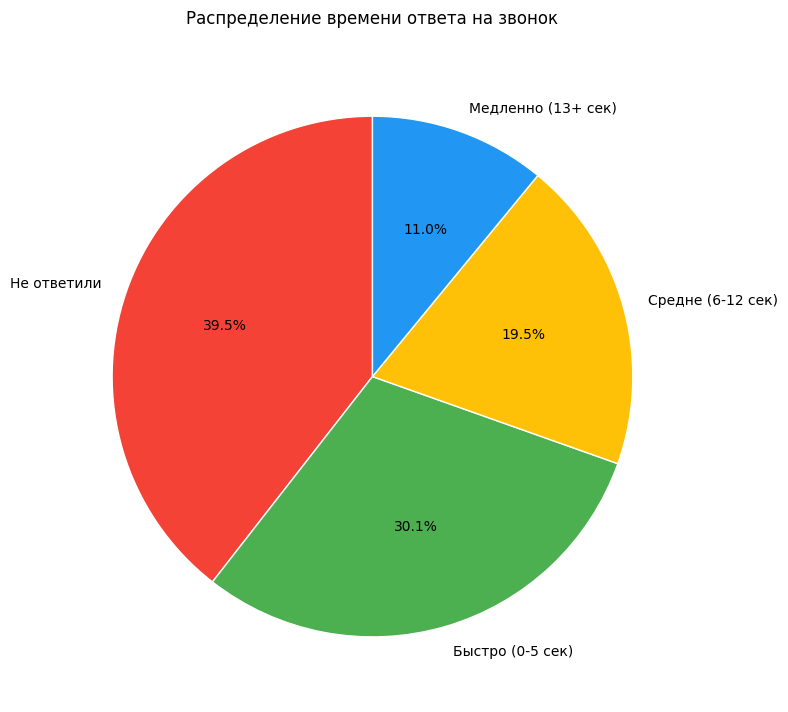

In [32]:
# Создаем категории на основе времени ответа
bins = [-2, -1, 5, 12, float('inf')]
labels = ['Не ответили', 'Быстро (0-5 сек)', 'Средне (6-12 сек)', 'Медленно (13+ сек)']
answer_delay = pd.cut(df_prepared['Answer_Delay'], bins=bins, labels=labels)

# Считаем количество в каждой категории
delay_counts = answer_delay.value_counts()

# Создаем круговую диаграмму
plt.figure(figsize=(8, 8))
plt.pie(
    delay_counts,
    labels=labels,
    autopct='%1.1f%%',  # Проценты с 1 знаком после запятой
    startangle=90,      # Первая долька вертикально
    colors=['#F44336', '#4CAF50', '#FFC107', '#2196F3'],  # Зеленый, желтый, красный
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}  # Границы долек
)

# Добавляем заголовок
plt.title('Распределение времени ответа на звонок', pad=20)
plt.tight_layout()
plt.show()

#### Создадим признаки с датой, часом и днём недели звонка/ответа

In [33]:
def extract_time_features(df, call_col='Call_Time', answer_col='Answer_Time'):
    """
    Извлекает временные признаки из колонок с датой/временем звонка и ответа.
    
    Параметры:
        df (pd.DataFrame): Исходный DataFrame
        call_col (str): Название колонки с временем звонка
        answer_col (str): Название колонки с временем ответа
    
    Возвращает:
        pd.DataFrame: DataFrame с добавленными признаками
    """
    # Копируем DataFrame чтобы избежать предупреждений
    df = df.copy()
    
    # Словарь для названий дней недели
    day_names = {
        0: 'Понедельник',
        1: 'Вторник',
        2: 'Среда',
        3: 'Четверг',
        4: 'Пятница',
        5: 'Суббота',
        6: 'Воскресенье'
    }
      
    # Признаки для времени звонка
    df['Call_Hour'] = df[call_col].dt.hour
    df['Call_Dayofweek'] = df[call_col].dt.dayofweek.map(day_names)  # Название дня
    # Создаем колонку Call_Day в datetime
    df['Call_Day'] = df[call_col].dt.date
        
    # Признаки для времени ответа
    df['Answer_Hour'] = df[answer_col].dt.hour
    df['Answer_Dayofweek'] = df[answer_col].dt.dayofweek.map(day_names)
    # Создаем колонку Answer_Day в datetime
    df['Answer_Day'] = df[answer_col].dt.date
     
    # Заполняем пропуски (можно изменить на другое значение)
    time_features = [
        'Call_Hour', 'Call_Dayofweek', 'Call_Day', 'Answer_Hour',
        'Answer_Dayofweek', 'Answer_Day',
    ]
    df[time_features] = df[time_features].fillna(-1)
    
    return df

df_prepared = extract_time_features(df_prepared)
print(df_prepared['Call_Day'].value_counts())
print(df_prepared['Call_Day'].info())

Call_Day
-1            33830
2025-06-01     6515
2025-06-02     6386
2025-06-04     5912
2025-06-09     5306
2025-06-08     5157
2025-06-16     4965
2025-06-15     4961
2025-06-11     4849
2025-06-05     4500
2025-06-18     4399
2025-06-07     4395
2025-06-06     4344
2025-06-03     4323
2025-06-12     4308
2025-06-14     4184
2025-06-13     4016
2025-06-19     3933
2025-06-17     3868
2025-06-10     3711
2025-06-20     3486
Name: count, dtype: int64
<class 'pandas.core.series.Series'>
RangeIndex: 127348 entries, 0 to 127347
Series name: Call_Day
Non-Null Count   Dtype 
--------------   ----- 
127348 non-null  object
dtypes: object(1)
memory usage: 995.0+ KB
None


#### Удаляем признаки после обработки

In [34]:
df_prepared = df_prepared.drop(columns=['Call_Time', 'Answer_Time', 'End_Time'], errors='ignore')

In [35]:
df_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127348 entries, 0 to 127347
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Plan_Name         127348 non-null  object 
 1   CALL_ID           127348 non-null  int64  
 2   Phone_Number      127348 non-null  int64  
 3   Robot             127348 non-null  object 
 4   Duration(s)       127348 non-null  int64  
 5   Talk_Round        127348 non-null  int64  
 6   Ring_Type         93518 non-null   object 
 7   Hang_Type         127348 non-null  object 
 8   Ring_Time         127348 non-null  int64  
 9   Intention         127348 non-null  object 
 10  Event_Labels      7385 non-null    object 
 11  ASR_Result        43581 non-null   object 
 12  Status            127348 non-null  object 
 13  DueDate/due_date  127348 non-null  object 
 14  day               127348 non-null  int64  
 15  Task_Name_dt      127348 non-null  object 
 16  Task_Name_bill    12

### Event_Labels удаляем, т.к. малоинформативен и данных очень мало

### ASR_Result

#### Заменяем на два признака - количество фраз и наличие автоответчика

In [36]:
def detect_voicemail(text):
    """
    Определяет, был ли автоответчик, по следующим признакам:
    1. Во второй фразе есть "User"
    2. Есть ключевые слова автоответчика
    3. Диалог слишком короткий
    """
    phrases = [p.strip() for p in str(text).split('\n') if p.strip()]
    
    # Если во второй фразе есть User - вероятно автоответчик
    if len(phrases) >= 2 and "User:" in phrases[1]:
        return 1
    elif text == -1:
        return -1
     
    return 0

def process_call_logs(df, text_column='ASR_Result'):
    """
    Обрабатывает логи звонков и создает:
    - phrase_count: количество фраз
    - is_voicemail: флаг автоответчика (1 если да)
    """
    df = df.copy()
    
    df['Phrase_Count'] = df[text_column].apply(
        lambda x: len([p for p in str(x).split('\n') if p.strip()]))
    
    df['Is_Voicemail'] = df[text_column].apply(detect_voicemail)
    
    return df

In [37]:
# Заменяем пустые на -1 для детекции
df_prepared['ASR_Result'] = df_prepared['ASR_Result'].fillna(-1)
df_prepared = process_call_logs(df_prepared)
print(df_prepared['Is_Voicemail'].value_counts())

Is_Voicemail
-1    83767
 1    34887
 0     8694
Name: count, dtype: int64


#### Удаляем оригинальный столбец

In [38]:
df_prepared = df_prepared.drop(columns=['ASR_Result'])

### DueDate/due_date

#### Преобразуем в формат месяц-день

In [39]:
df_prepared['DueDate/due_date'] = pd.to_datetime(df_prepared['DueDate/due_date'], errors='coerce', format='%Y-%m-%d').dt.date
print(df_prepared['DueDate/due_date'].value_counts())
print(df_prepared['DueDate/due_date'].info())

DueDate/due_date
2025-06-09    12552
2025-06-16    11351
2025-06-11     7447
2025-06-20     6789
2025-06-02     6673
2025-06-10     6581
2025-06-13     6552
2025-06-17     6444
2025-06-05     6402
2025-06-19     6400
2025-06-06     6155
2025-06-18     6003
2025-06-12     5995
2025-06-23     5174
2025-06-04     5007
2025-06-03     3568
2025-06-14     2647
2025-06-21     2398
2025-06-08     2144
2025-06-24     2108
2025-06-15     1998
2025-06-07     1968
2025-06-25     1456
2025-06-22     1434
2025-05-30      951
2025-05-29      470
2025-05-28      360
2025-06-01      300
2025-05-31       21
Name: count, dtype: int64
<class 'pandas.core.series.Series'>
RangeIndex: 127348 entries, 0 to 127347
Series name: DueDate/due_date
Non-Null Count   Dtype 
--------------   ----- 
127348 non-null  object
dtypes: object(1)
memory usage: 995.0+ KB
None


### day

#### Приводим к единому формату

In [40]:
df_prepared['day'] = pd.to_datetime("2025-06-" + df_prepared['day'].astype(str).str.zfill(2), errors='coerce')
df_prepared['day'].value_counts()

day
2025-06-01    8933
2025-06-02    8415
2025-06-04    8316
2025-06-09    6959
2025-06-08    6866
2025-06-15    6680
2025-06-11    6604
2025-06-16    6582
2025-06-18    6183
2025-06-05    6078
2025-06-06    5955
2025-06-20    5899
2025-06-07    5778
2025-06-03    5707
2025-06-12    5696
2025-06-13    5644
2025-06-14    5457
2025-06-19    5330
2025-06-17    5195
2025-06-10    5071
Name: count, dtype: int64

#### Преобразуем остальные пустые значения в -1 для детекции

In [41]:
df_prepared = df_prepared.fillna(-1)

In [42]:
df_prepared

,Plan_Name,CALL_ID,Phone_Number,Robot,Duration(s),Talk_Round,Ring_Type,Hang_Type,Ring_Time,Intention,Event_Labels,Status,DueDate/due_date,day,Task_Name_dt,Task_Name_bill,Task_Name_time,Task_Name_status,Phone_Code,Answer_Delay,Call_Hour,Call_Dayofweek,Call_Day,Answer_Hour,Answer_Dayofweek,Answer_Day,Phrase_Count,Is_Voicemail
0,-1,0,0,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-01,2025-06-01,06-01,0,14:30,New,844,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1
1,-1,0,1,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-01,2025-06-01,06-01,0,14:30,New,332,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1
2,-1,0,2,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-04,2025-06-01,06-01,-3,18:00,New_first,818,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1
3,-1,0,3,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-04,2025-06-01,06-01,-3,18:00,New_first,951,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1
4,-1,0,4,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-04,2025-06-01,06-01,-3,18:00,New_first,771,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127343,-1,1,3064,M0_L2_MX_ES_Adr_COZMO_DM2_v4,2,1,outofarea,ByRobot,8,G,-1,finished,2025-06-20,2025-06-20,06-20,0,07:45,Repeat,954,10.0,7.0,Пятница,2025-06-20,7.0,Пятница,2025-06-20,2,1
127344,-1,1,6723,M0_L2_MX_ES_Adr_COZMO_DM2_v4,2,1,normal,ByRobot,27,G,-1,finished,2025-06-20,2025-06-20,06-20,0,07:45,Repeat,554,29.0,7.0,Пятница,2025-06-20,7.0,Пятница,2025-06-20,2,1
127345,-1,1,5034,M0_L2_MX_ES_Adr_COZMO_DM2_v4,1,1,busy,ByRobot,8,G,-1,finished,2025-06-20,2025-06-20,06-20,0,07:45,Repeat,663,10.0,7.0,Пятница,2025-06-20,7.0,Пятница,2025-06-20,2,1
127346,-1,1,2842,M0_L2_MX_ES_Adr_COZMO_DM2_v4,2,1,normal,ByRobot,8,G,-1,finished,2025-06-20,2025-06-20,06-20,0,07:45,Repeat,557,10.0,7.0,Пятница,2025-06-20,7.0,Пятница,2025-06-20,2,1


### Проверим связь Task_Name_dt и Plan_Name

#### По количеству

In [43]:
link_tn = df_prepared[df_prepared['Task_Name_dt'] == 'airudder'] # Проблемные строки в Task_Name_dt
link_pn = df_prepared[df_prepared['Plan_Name'] != -1] # Проблемные строки в Plan_Name
print(f'Одинаковое кол-во? - {len(link_tn) == len(link_pn)}')

Одинаковое кол-во? - True


#### По количеству такое же- проверим по совпадению строк

In [44]:
len(link_tn)
common_indices = link_pn.index.intersection(link_tn.index)
print(f"Количество общих индексов: {len(common_indices)}")

Количество общих индексов: 2369


#### Выведем строки с airudder для анализа

#### Данные те же- видимо это результат работы робота M0_L2_MX_ES_Adr_COZMO_DM2_PTP.
#### Количество строк то же, поэтому можно вычислить позже.
#### Пока переносим из Plan_Name в Task_Name_dt строки дат и удалим Plan_Name

In [45]:
mask_task = df_prepared['Task_Name_dt'] == 'airrudder'
mask_plan = df_prepared['Plan_Name'] != -1

# Берём только пересекающиеся индексы
common_indices = df_prepared[mask_task].index.intersection(df_prepared[mask_plan].index)

# Переносим данные только для общих строк
df_prepared.loc[common_indices, 'Task_Name_dt'] = df_prepared.loc[common_indices, 'Plan_Name']
df_prepared['Task_Name_dt'].value_counts()

# Находим индексы, где Task_Name_dt == 'airudder' И Plan_Name != -1
mask = (df_prepared['Task_Name_dt'] == 'airudder') & (df_prepared['Plan_Name'] != -1)
df_prepared.loc[mask, 'Task_Name_dt'] = df_prepared.loc[mask, 'Plan_Name']

# Удаляем столбец Plan_Name
df_prepared = df_prepared.drop(columns=['Plan_Name'], errors='ignore')

# Проверяем результат
print(df_prepared['Task_Name_dt'].value_counts())

Task_Name_dt
06-01    8933
06-02    8415
06-04    8316
06-09    6959
06-08    6866
06-15    6680
06-11    6604
06-16    6582
06-18    6183
06-05    6078
06-06    5955
06-20    5899
06-07    5778
06-03    5707
06-12    5696
06-13    5644
06-14    5457
06-19    5330
06-17    5195
06-10    5071
Name: count, dtype: int64


#### Преобразуем в формат даты

In [46]:
df_prepared['Task_Name_dt'] = pd.to_datetime("2025-" + df_prepared['Task_Name_dt'], format="%Y-%m-%d")
print(df_prepared['Task_Name_dt'].value_counts())
print(df_prepared['Task_Name_dt'].info())

Task_Name_dt
2025-06-01    8933
2025-06-02    8415
2025-06-04    8316
2025-06-09    6959
2025-06-08    6866
2025-06-15    6680
2025-06-11    6604
2025-06-16    6582
2025-06-18    6183
2025-06-05    6078
2025-06-06    5955
2025-06-20    5899
2025-06-07    5778
2025-06-03    5707
2025-06-12    5696
2025-06-13    5644
2025-06-14    5457
2025-06-19    5330
2025-06-17    5195
2025-06-10    5071
Name: count, dtype: int64
<class 'pandas.core.series.Series'>
RangeIndex: 127348 entries, 0 to 127347
Series name: Task_Name_dt
Non-Null Count   Dtype         
--------------   -----         
127348 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 995.0 KB
None


#### Создадим признак дня недели на основе Task_Name_dt

In [47]:
df_prepared['Task_Name_dt'] = pd.to_datetime(df_prepared['Task_Name_dt'])
df_prepared['Task_Name_dw'] = df_prepared['Task_Name_dt'].dt.dayofweek

# Дополнительно можно создать колонку с названиями дней
day_names = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

df_prepared['Task_Name_dw'] = df_prepared['Task_Name_dw'].map(day_names)

# Проверяем результат
print(df_prepared['Task_Name_dw'].value_counts())

Task_Name_dw
Воскресенье    22479
Понедельник    21956
Среда          21103
Пятница        17498
Четверг        17104
Вторник        15973
Суббота        11235
Name: count, dtype: int64


#### Сохраняем в новый CSV-файл

In [48]:
df_prepared.to_csv("prepared.csv", index=False)

In [49]:
df0 = pd.read_csv('prepared.csv')

In [50]:
df = df0.copy()

In [51]:
df

,CALL_ID,Phone_Number,Robot,Duration(s),Talk_Round,Ring_Type,Hang_Type,Ring_Time,Intention,Event_Labels,Status,DueDate/due_date,day,Task_Name_dt,Task_Name_bill,Task_Name_time,Task_Name_status,Phone_Code,Answer_Delay,Call_Hour,Call_Dayofweek,Call_Day,Answer_Hour,Answer_Dayofweek,Answer_Day,Phrase_Count,Is_Voicemail,Task_Name_dw
0,0,0,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-01,2025-06-01,2025-06-01,0,14:30,New,844,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1,Воскресенье
1,0,1,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-01,2025-06-01,2025-06-01,0,14:30,New,332,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1,Воскресенье
2,0,2,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-04,2025-06-01,2025-06-01,-3,18:00,New_first,818,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1,Воскресенье
3,0,3,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-04,2025-06-01,2025-06-01,-3,18:00,New_first,951,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1,Воскресенье
4,0,4,M0_L2_MX_ES_Adr_COZMO_DM2_v4,0,0,-1,Cancelled,0,--,-1,cancelled,2025-06-04,2025-06-01,2025-06-01,-3,18:00,New_first,771,-1.0,-1.0,-1,-1,-1.0,-1,-1,1,-1,Воскресенье
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127343,1,3064,M0_L2_MX_ES_Adr_COZMO_DM2_v4,2,1,outofarea,ByRobot,8,G,-1,finished,2025-06-20,2025-06-20,2025-06-20,0,07:45,Repeat,954,10.0,7.0,Пятница,2025-06-20,7.0,Пятница,2025-06-20,2,1,Пятница
127344,1,6723,M0_L2_MX_ES_Adr_COZMO_DM2_v4,2,1,normal,ByRobot,27,G,-1,finished,2025-06-20,2025-06-20,2025-06-20,0,07:45,Repeat,554,29.0,7.0,Пятница,2025-06-20,7.0,Пятница,2025-06-20,2,1,Пятница
127345,1,5034,M0_L2_MX_ES_Adr_COZMO_DM2_v4,1,1,busy,ByRobot,8,G,-1,finished,2025-06-20,2025-06-20,2025-06-20,0,07:45,Repeat,663,10.0,7.0,Пятница,2025-06-20,7.0,Пятница,2025-06-20,2,1,Пятница
127346,1,2842,M0_L2_MX_ES_Adr_COZMO_DM2_v4,2,1,normal,ByRobot,8,G,-1,finished,2025-06-20,2025-06-20,2025-06-20,0,07:45,Repeat,557,10.0,7.0,Пятница,2025-06-20,7.0,Пятница,2025-06-20,2,1,Пятница



Столбец: CALL_ID
CALL_ID
1    93518
0    33830
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


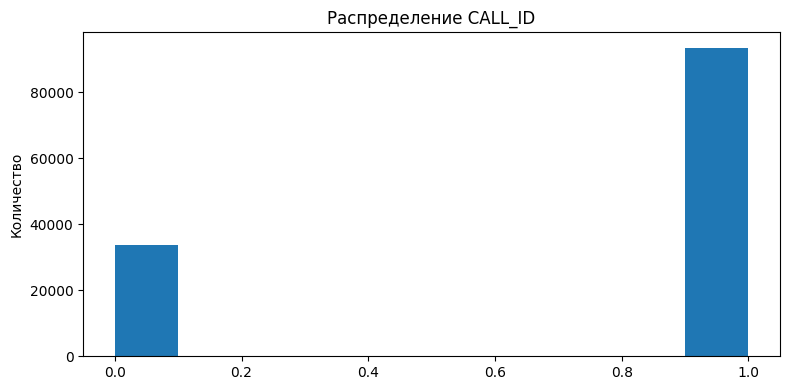


Столбец: Phone_Number
Phone_Number
5684    78
3550    63
1388    61
2007    60
3558    60
        ..
5415     1
2977     1
5411     1
2758     1
3730     1
Name: count, Length: 10352, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


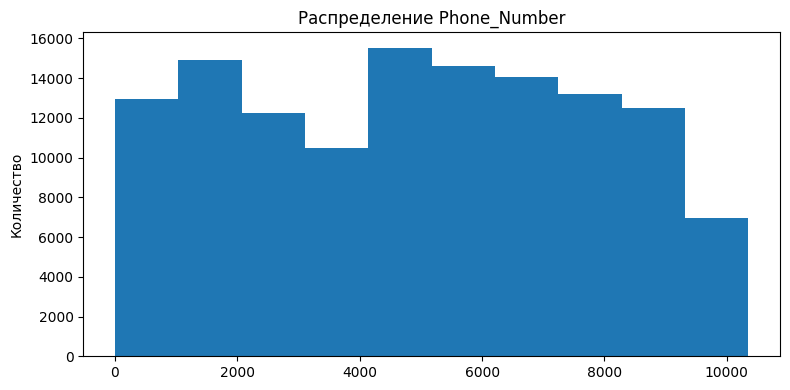


Столбец: Robot
Robot
M0_L2_MX_ES_Adr_COZMO_DM2_v4     120190
M1_L2_MX_ES_Adr_COZMO_DM2_v4       4789
M0_L2_MX_ES_Adr_COZMO_DM2_PTP      2369
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


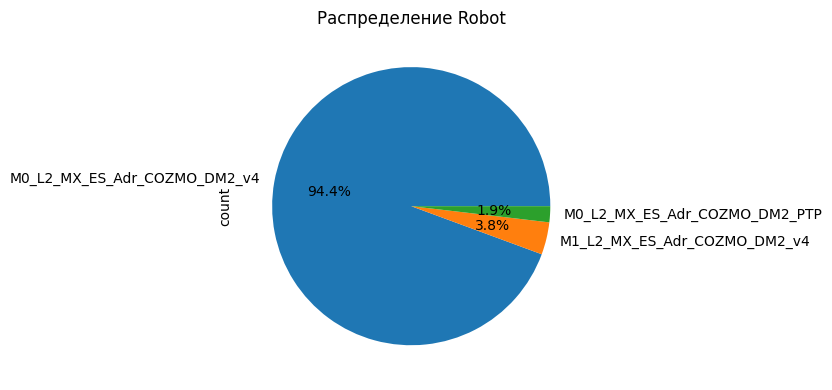


Столбец: Duration(s)
Duration(s)
0      83764
2      18602
1       7949
3       6452
4        987
       ...  
132        1
149        1
148        1
130        1
146        1
Name: count, Length: 146, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


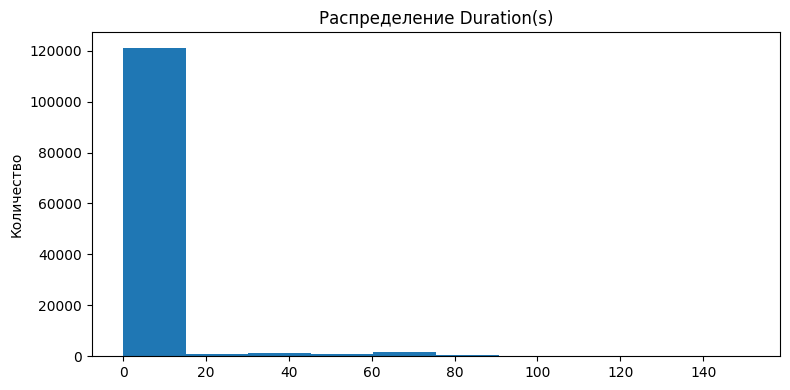


Столбец: Talk_Round
Talk_Round
0     86320
1     35384
2      1315
5      1295
4      1073
3       762
6       692
7       262
8       141
9        63
10       28
11        7
12        4
14        1
13        1
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


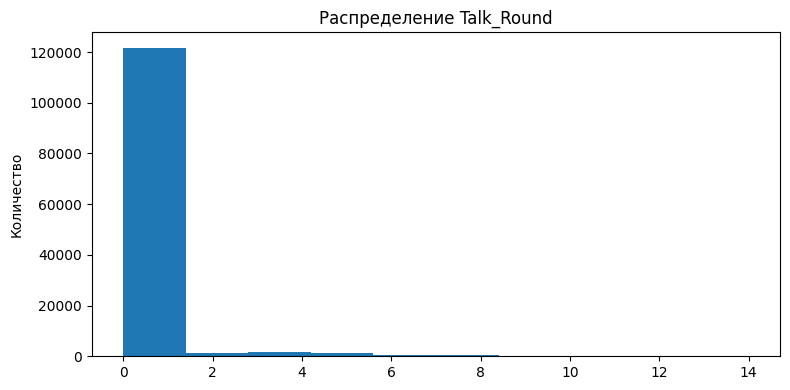


Столбец: Ring_Type
Ring_Type
normal       61736
-1           33830
busy         13643
outofarea    11970
switchoff     2517
wrongnum      2300
holdline      1352
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


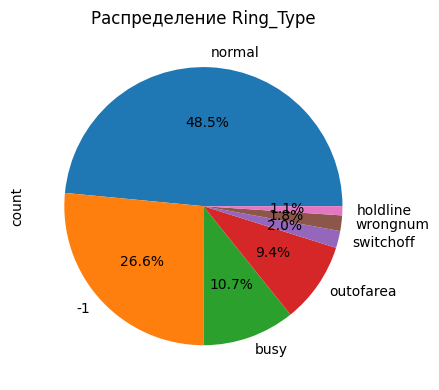


Столбец: Hang_Type
Hang_Type
ByRobot      74985
Cancelled    29281
ByUser       23082
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


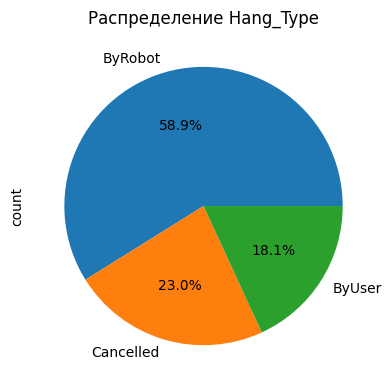


Столбец: Ring_Time
Ring_Time
0     36355
29    17097
28    15038
9      5099
8      4868
      ...  
65        1
86        1
80        1
84        1
77        1
Name: count, Length: 84, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


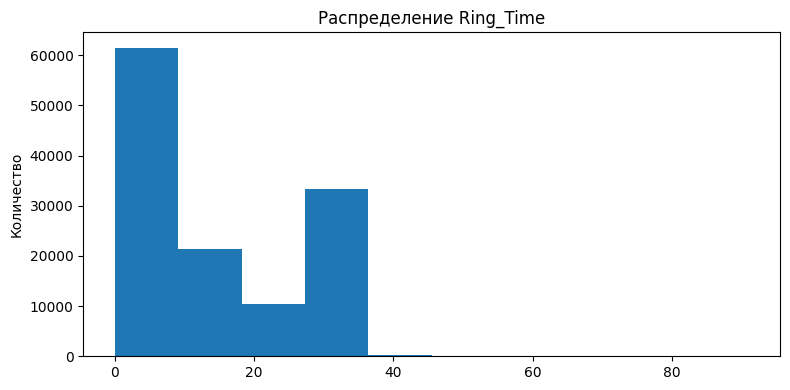


Столбец: Intention
Intention
F     49934
G     34696
--    33830
A      3490
J      2480
K       895
L       836
E       482
D       344
C       194
B       137
H        30
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


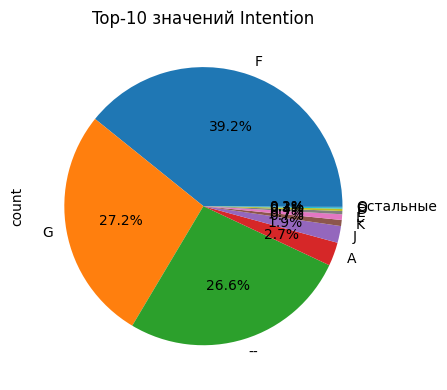


Столбец: Event_Labels
Event_Labels
-1                                              119963
{"Result_E":"E1_silence"}                         2778
{"promise_to_pay":"willing_to_pay"}               1720
{"promise_to_pay":"willing_to_extend"}            1454
{"Result_E":"E3_hangup_after_verification"}        888
{"Result_E":"E2_hangup_and_no_verification"}       545
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


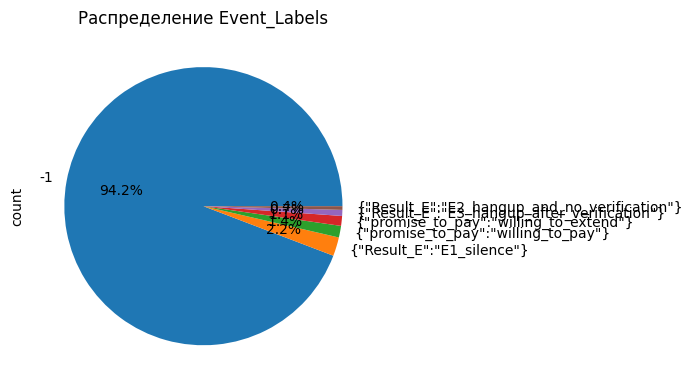


Столбец: Status
Status
failed       49607
finished     43584
cancelled    33464
pending        693
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


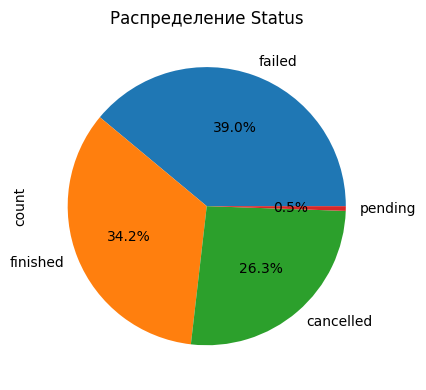


Столбец: DueDate/due_date
DueDate/due_date
2025-06-09    12552
2025-06-16    11351
2025-06-11     7447
2025-06-20     6789
2025-06-02     6673
2025-06-10     6581
2025-06-13     6552
2025-06-17     6444
2025-06-05     6402
2025-06-19     6400
2025-06-06     6155
2025-06-18     6003
2025-06-12     5995
2025-06-23     5174
2025-06-04     5007
2025-06-03     3568
2025-06-14     2647
2025-06-21     2398
2025-06-08     2144
2025-06-24     2108
2025-06-15     1998
2025-06-07     1968
2025-06-25     1456
2025-06-22     1434
2025-05-30      951
2025-05-29      470
2025-05-28      360
2025-06-01      300
2025-05-31       21
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


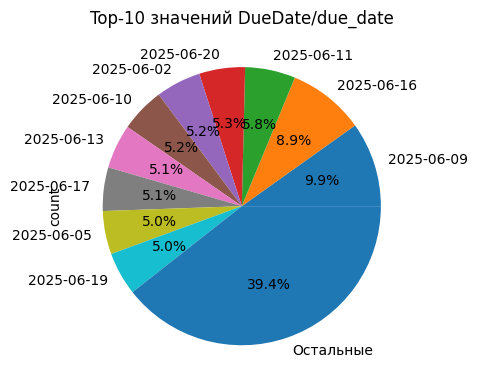


Столбец: day
day
2025-06-01    8933
2025-06-02    8415
2025-06-04    8316
2025-06-09    6959
2025-06-08    6866
2025-06-15    6680
2025-06-11    6604
2025-06-16    6582
2025-06-18    6183
2025-06-05    6078
2025-06-06    5955
2025-06-20    5899
2025-06-07    5778
2025-06-03    5707
2025-06-12    5696
2025-06-13    5644
2025-06-14    5457
2025-06-19    5330
2025-06-17    5195
2025-06-10    5071
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


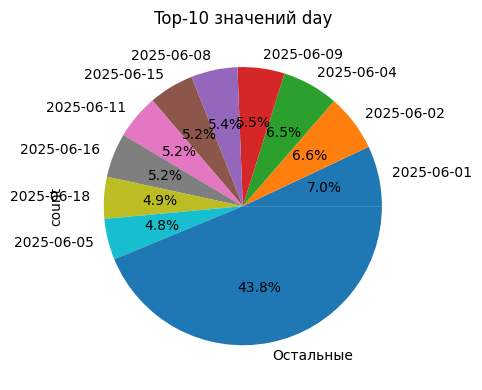


Столбец: Task_Name_dt
Task_Name_dt
2025-06-01    8933
2025-06-02    8415
2025-06-04    8316
2025-06-09    6959
2025-06-08    6866
2025-06-15    6680
2025-06-11    6604
2025-06-16    6582
2025-06-18    6183
2025-06-05    6078
2025-06-06    5955
2025-06-20    5899
2025-06-07    5778
2025-06-03    5707
2025-06-12    5696
2025-06-13    5644
2025-06-14    5457
2025-06-19    5330
2025-06-17    5195
2025-06-10    5071
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


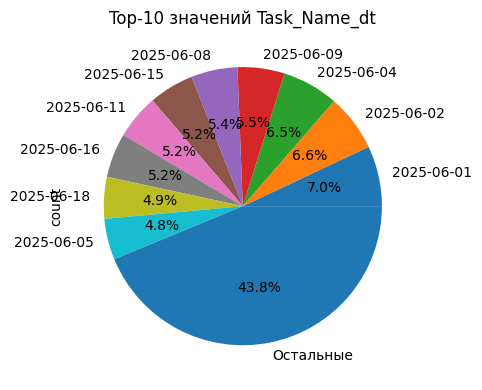


Столбец: Task_Name_bill
Task_Name_bill
-5    27954
-1    21515
-3    20071
-2    18815
 0    17256
-4    14579
 2     4074
 4     1687
 1     1397
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


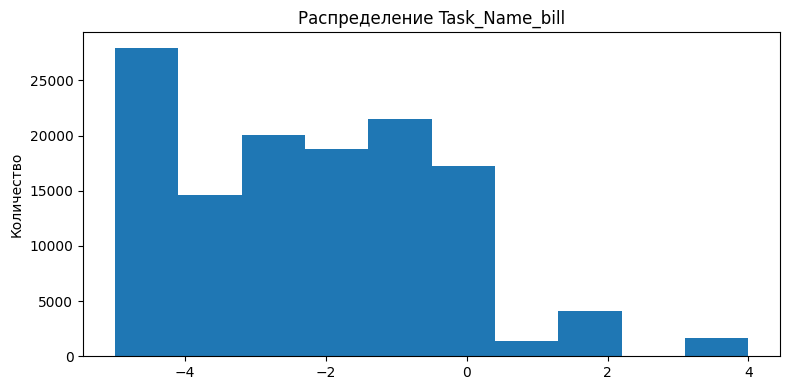


Столбец: Task_Name_time
Task_Name_time
07:45    37701
18:00    30516
10:30    23959
12:30    18269
14:30     9745
8:30      2521
-1        2369
18:30     2268
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


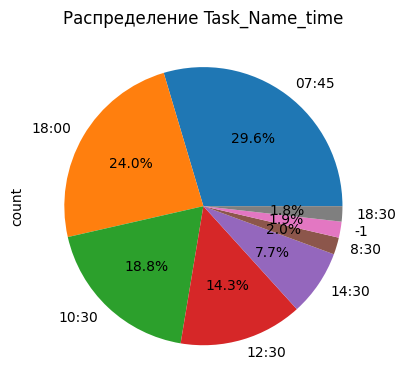


Столбец: Task_Name_status
Task_Name_status
Repeat          62517
New             30271
New_first       15568
Repeat_first    10431
-1               7158
New_frist        1403
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


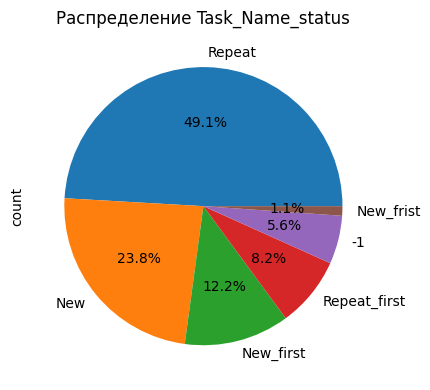


Столбец: Phone_Code
Phone_Code
554    5011
553    4980
552    4086
551    3559
557    3144
       ... 
463       4
696       4
988       2
823       2
593       2
Name: count, Length: 321, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


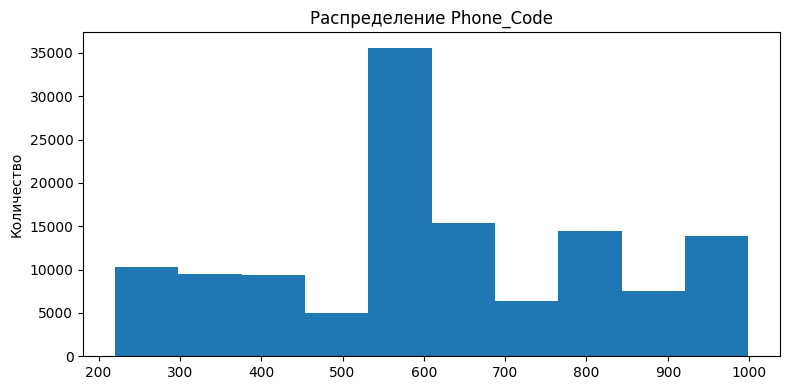


Столбец: Answer_Delay
Answer_Delay
 0.0     45425
-1.0     38339
 11.0     3329
 10.0     3062
 12.0     2954
         ...  
 90.0        1
 63.0        1
 66.0        1
 57.0        1
 89.0        1
Name: count, Length: 76, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


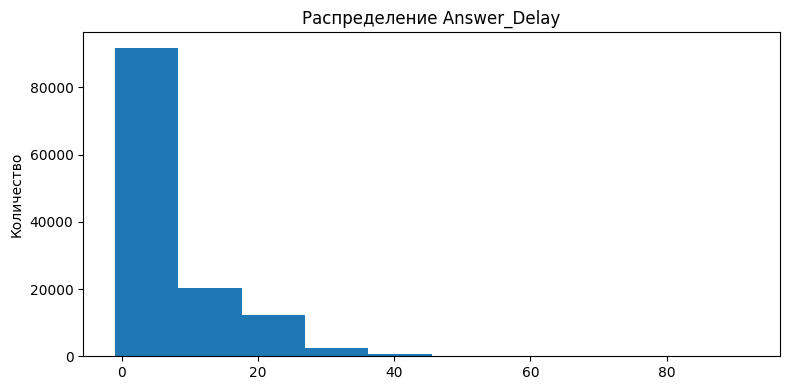


Столбец: Call_Hour
Call_Hour
-1.0     33830
 9.0     17782
 7.0     16491
 18.0    12078
 11.0     9811
 13.0     7607
 10.0     7263
 19.0     6334
 8.0      5841
 15.0     4645
 12.0     2829
 14.0     2546
 16.0      290
 20.0        1
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


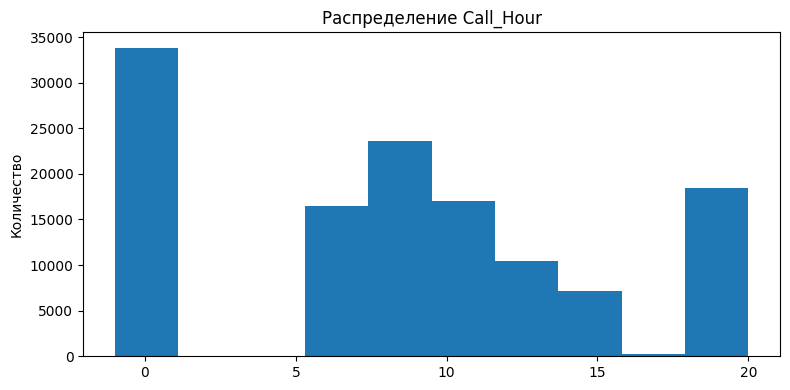


Столбец: Call_Dayofweek
Call_Dayofweek
-1             33830
Понедельник    16657
Воскресенье    16633
Среда          15160
Четверг        12741
Вторник        11902
Пятница        11846
Суббота         8579
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


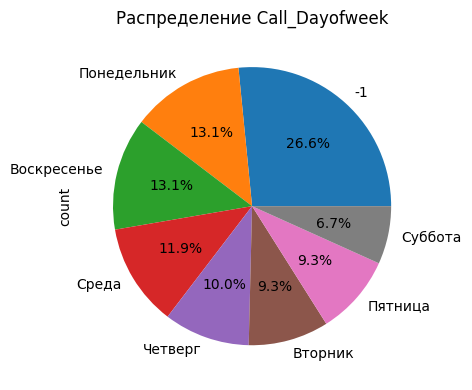


Столбец: Call_Day
Call_Day
-1            33830
2025-06-01     6515
2025-06-02     6386
2025-06-04     5912
2025-06-09     5306
2025-06-08     5157
2025-06-16     4965
2025-06-15     4961
2025-06-11     4849
2025-06-05     4500
2025-06-18     4399
2025-06-07     4395
2025-06-06     4344
2025-06-03     4323
2025-06-12     4308
2025-06-14     4184
2025-06-13     4016
2025-06-19     3933
2025-06-17     3868
2025-06-10     3711
2025-06-20     3486
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


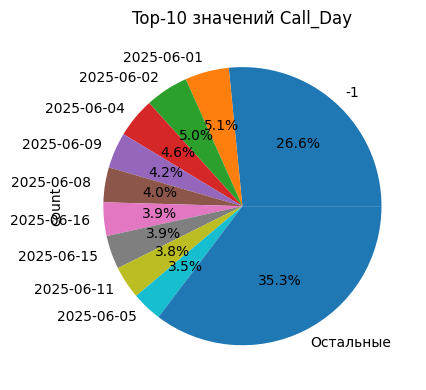


Столбец: Answer_Hour
Answer_Hour
-1.0     38339
 7.0     16491
 9.0     16458
 18.0    11366
 11.0     9164
 10.0     7264
 13.0     7064
 19.0     5996
 8.0      5836
 15.0     4216
 14.0     2522
 12.0     2341
 16.0      290
 20.0        1
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


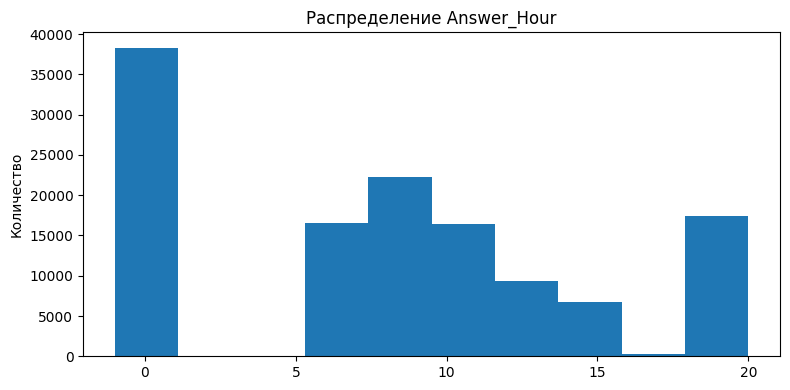


Столбец: Answer_Dayofweek
Answer_Dayofweek
-1             38339
Понедельник    16657
Воскресенье    16633
Среда          14609
Вторник        11902
Четверг        10571
Пятница        10058
Суббота         8579
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


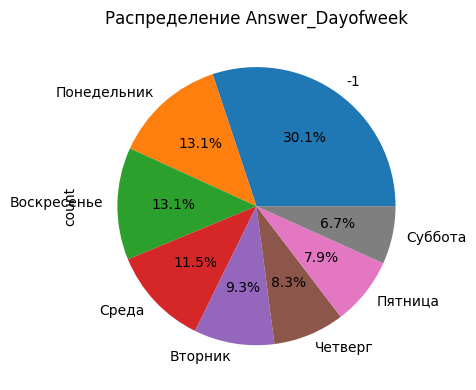


Столбец: Answer_Day
Answer_Day
-1            38339
2025-06-01     6515
2025-06-02     6386
2025-06-04     5912
2025-06-09     5306
2025-06-08     5157
2025-06-16     4965
2025-06-15     4961
2025-06-11     4849
2025-06-05     4500
2025-06-07     4395
2025-06-06     4344
2025-06-03     4323
2025-06-12     4308
2025-06-14     4184
2025-06-13     4016
2025-06-17     3868
2025-06-18     3848
2025-06-10     3711
2025-06-19     1763
2025-06-20     1698
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


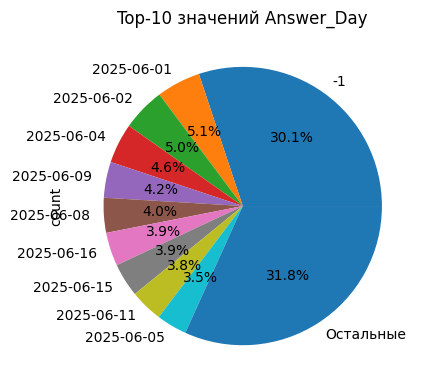


Столбец: Phrase_Count
Phrase_Count
1     84531
2     29972
3      5746
4      1146
6       897
12      807
10      658
5       512
8       501
11      493
13      456
9       360
7       346
14      295
15      179
16      148
17       83
18       67
19       44
20       33
21       28
22       18
23       16
24        4
26        3
25        2
28        1
27        1
30        1
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


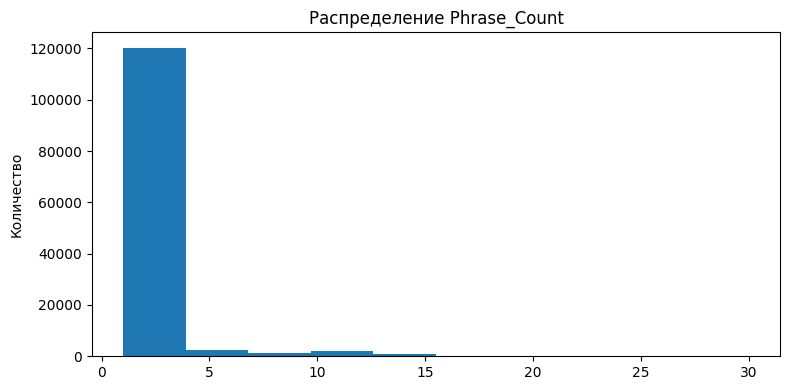


Столбец: Is_Voicemail
Is_Voicemail
-1    83767
 1    34887
 0     8694
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


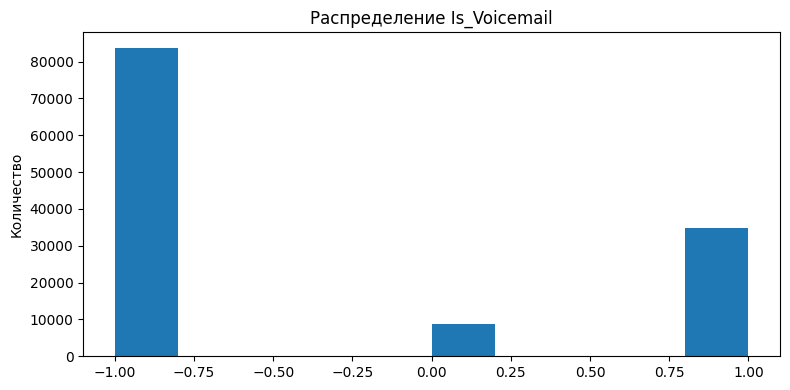


Столбец: Task_Name_dw
Task_Name_dw
Воскресенье    22479
Понедельник    21956
Среда          21103
Пятница        17498
Четверг        17104
Вторник        15973
Суббота        11235
Name: count, dtype: int64
Всего: 127348 | Полных: 127348 | Пустых: 0
--------------------------------------------------


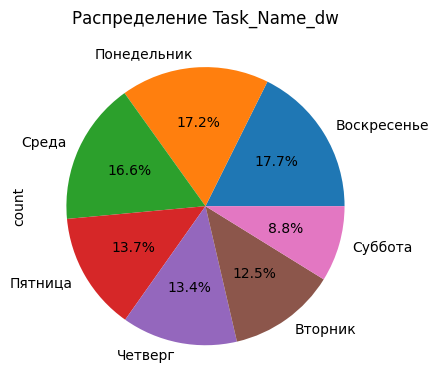


Общая информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127348 entries, 0 to 127347
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CALL_ID           127348 non-null  int64  
 1   Phone_Number      127348 non-null  int64  
 2   Robot             127348 non-null  object 
 3   Duration(s)       127348 non-null  int64  
 4   Talk_Round        127348 non-null  int64  
 5   Ring_Type         127348 non-null  object 
 6   Hang_Type         127348 non-null  object 
 7   Ring_Time         127348 non-null  int64  
 8   Intention         127348 non-null  object 
 9   Event_Labels      127348 non-null  object 
 10  Status            127348 non-null  object 
 11  DueDate/due_date  127348 non-null  object 
 12  day               127348 non-null  object 
 13  Task_Name_dt      127348 non-null  object 
 14  Task_Name_bill    127348 non-null  int64  
 15  Task_Name_time    127348 non-null  ob

In [56]:
df = prepare(df, inffo=True, plot_pie=True)